In [1]:
import gc
gc.collect()

import sys
# Add necessary paths to sys.path
for path in ['/afs/psi.ch/intranet/SF/Beamdynamics/Harsh/gpsr/', '/afs/psi.ch/intranet/SF/Beamdynamics/Harsh/']:
    if path not in sys.path:
        sys.path.append(path)

import h5py
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Subset # Import Subset for splitting

# Import custom modules
from ps_reconstruction.core.image_processing import crop_images_to_bright_spot_centers
from ps_reconstruction.core.dataloader import BeamImageDataset, create_beam_dataloader, beam_collate_fn # Ensure beam_collate_fn is also imported
from ps_reconstruction.core.simulation import ScreenImageGenerator
from ps_reconstruction.core.beam_generator import ParticleTransformer, NNParticleBeamGenerator, NNTransform
from ps_reconstruction.core.train import train_beam_generator_with_dataloader
from ps_reconstruction.utils import plot_original_predicted_difference

In [2]:
# Load the HDF5 file
dfile = '/sf/data/measurements/2025/05/22/20250522_212838_EmittanceTool.h5'
with h5py.File(dfile, 'r') as f:
    # Store original data (before slicing) for ScreenImageGenerator __init__
    original_r11 = f['/Input/R11'][()]
    original_r12 = f['/Input/R12'][()]
    original_r33 = f['/Input/R33'][()]
    original_r34 = f['/Input/R34'][()]
    original_quad_k = f['/Input/QuadK'][()] # shape: (n_phases,)
    p0c = f['/Input/energy_eV'][()]
    images = f['/Raw_data/image'][()]  # shape: (n_phases, n_images, y, x)
    x_axis = f['/Raw_data/x_axis'][0,0].astype(float)/1e6  # shape: (x,)
    y_axis = f['/Raw_data/y_axis'][0,0].astype(float)/1e6  # shape: (y,)
    screen_res = f['/Input/screen_resolution'][()] # e.g., (100, 100)

# Apply background subtraction
proc_images = np.array(images, dtype=np.float64) - 1000
proc_images[proc_images < 0 ] = 0

# Select specific indices to use
# This selects the images and corresponding R-matrix values.
# Ensure 'to_use_indices' aligns with the dimensions of original_rXX and proc_images
to_use_indices = [3,4,5,6,7,9,13,14,15,16]
to_use_indices.extend(list(int(i) for i in np.arange(20,30,1)))

# Crop images to bright spot centers (apply to the first image of each phase for now)
processed_images_array, processed_x_axis, processed_y_axis = crop_images_to_bright_spot_centers(
    proc_images[:, 0], # Assuming you always use the first image from n_images dimension
    target_x=120, 
    target_y=120, 
    x_axis=x_axis, 
    y_axis=y_axis
)

# Filter all data by to_use_indices
filtered_r11 = original_r11[to_use_indices]
filtered_r12 = original_r12[to_use_indices]
filtered_r33 = original_r33[to_use_indices]
filtered_r34 = original_r34[to_use_indices]
filtered_quad_k = original_quad_k[-1][to_use_indices]

processed_tensors = torch.tensor(processed_images_array[to_use_indices], dtype=torch.float32)

# Ensure R-matrix and quad_k are 1D arrays of values for direct mapping to each sample
# (The DataLoader will stack them later)
quad_torch_k_for_dataset = torch.tensor(filtered_quad_k, dtype=torch.float32).flatten() # Ensure 1D

# Calculate pixel sizes for the cropped images
x_pixel_size = abs(processed_x_axis[0][1] - processed_x_axis[0][0])
y_pixel_size = abs(processed_y_axis[0][1] - processed_y_axis[0][0])
x_pixel_size_tensor = torch.tensor(x_pixel_size, dtype=torch.float32)
y_pixel_size_tensor = torch.tensor(y_pixel_size, dtype=torch.float32)

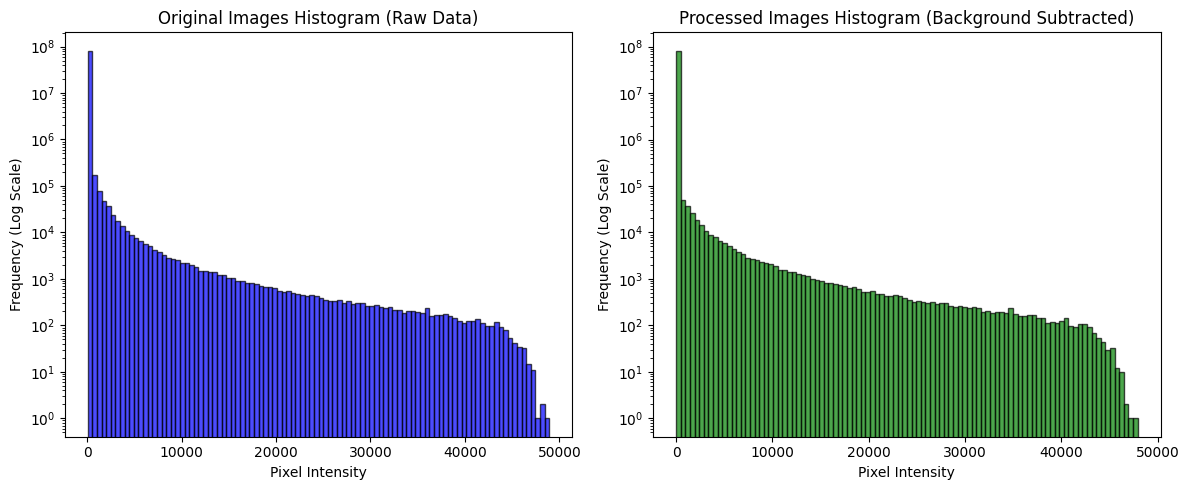

In [3]:
# Plot histograms for original and processed images
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot histogram for original images (full raw data)
axes[0].hist(np.ravel(images), bins=100, log=True, color='blue', alpha=0.7, edgecolor='black')
axes[0].set_title('Original Images Histogram (Raw Data)')
axes[0].set_xlabel('Pixel Intensity')
axes[0].set_ylabel('Frequency (Log Scale)')

# Plot histogram for processed images (after background subtraction, before cropping/slicing)
axes[1].hist(np.ravel(proc_images), bins=100, log=True, color='green', alpha=0.7, edgecolor='black')
axes[1].set_title('Processed Images Histogram (Background Subtracted)')
axes[1].set_xlabel('Pixel Intensity')
axes[1].set_ylabel('Frequency (Log Scale)')

plt.tight_layout()
plt.show()

In [4]:
# Function to split dataset (re-include it here for self-contained cell)
def split_dataset(dataset: BeamImageDataset, train_indices: list) -> tuple[Subset, Subset]:
    """
    Splits a BeamImageDataset into training and testing subsets based on provided indices.
    """
    train_indices_set = set(train_indices)
    all_indices = set(range(len(dataset)))
    test_indices_set = all_indices - train_indices_set
    train_indices_list = sorted(list(train_indices_set))
    test_indices_list = sorted(list(test_indices_set))
    train_subset = Subset(dataset, train_indices_list)
    test_subset = Subset(dataset, test_indices_list)
    return train_subset, test_subset

# Prepare data list for BeamImageDataset
# Each item in `data_list_for_dataset` represents ONE sample with its image and R-matrix parameters.
data_list_for_dataset = []
for i in range(len(to_use_indices)): # Iterate through the already-filtered data
    data_list_for_dataset.append({
        'image': processed_tensors[i], # This is a single 2D image tensor for this sample
        'r11': [filtered_r11[i]],       # A single r11 value for this sample
        'r12': [filtered_r12[i]],
        'r33': [filtered_r33[i]],
        'r34': [filtered_r34[i]],
        'quad_k': quad_torch_k_for_dataset[i] # A single quad_k value for this sample
    })

# Create the full dataset from the prepared list
full_filtered_dataset = BeamImageDataset(data_list_for_dataset)
print(f"Total samples in filtered dataset: {len(full_filtered_dataset)}")

# Define train and test indices for the split
# "alternate image used for training and rest for testing"
# This means: train = 0, 2, 4, ... ; test = 1, 3, 5, ...
all_filtered_indices = list(range(len(full_filtered_dataset)))
train_indices = [i for i in all_filtered_indices if i % 2 == 0]
test_indices = [i for i in all_filtered_indices if i % 2 != 0]
# train_indices = [0,1,2,3,4,6,8,10,12,14,16,17,18,19]
# test_indices = [5,7,9,11,13,15]

print(f"Train indices: {train_indices}")
print(f"Test indices: {test_indices}")

# Split the dataset
train_ds, test_ds = split_dataset(full_filtered_dataset, train_indices)

print(f"Train dataset size: {len(train_ds)}")
print(f"Test dataset size: {len(test_ds)}")

# Create DataLoaders for training and testing
# Using the custom collate_fn for proper batching of dicts
train_dataloader = DataLoader(train_ds, batch_size=5, shuffle=False, collate_fn=beam_collate_fn)
test_dataloader = DataLoader(test_ds, batch_size=len(test_ds), shuffle=False, collate_fn=beam_collate_fn)

Total samples in filtered dataset: 20
Train indices: [0, 2, 4, 6, 8, 10, 12, 14, 16, 18]
Test indices: [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]
Train dataset size: 10
Test dataset size: 10


/afs/psi.ch/intranet/SF/Beamdynamics/Harsh/ps_reconstruction/core/dataloader.py:42: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  quad_k = torch.tensor(item['quad_k'], dtype=torch.float32)


In [5]:
# Determine device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Initialize ScreenImageGenerator
# The r11, r12, r33, r34, quad_k provided here are the *initial* values used
# if generate_screen_image (without params) is called.
# For generate_screen_image_with_params (which we will use), the r-matrices
# are passed per batch. So, these can be set to the *full set of filtered* values.
screen_gen = ScreenImageGenerator(
    r11=filtered_r11, r12=filtered_r12, r33=filtered_r33, r34=filtered_r34, quad_k=filtered_quad_k,
    x_pixels=processed_tensors.shape[2], y_pixels=processed_tensors.shape[1], # Use actual image shape
    x_pixel_size=x_pixel_size_tensor.item(), y_pixel_size=y_pixel_size_tensor.item(), # Pass as float
    device=device
)

# Initialize ParticleTransformer
transformer = ParticleTransformer(
    input_dim=4,      # Changed from 6 to 4
    model_dim=16,
    n_heads=4,
    num_layers=2,
    dim_feedforward=32,
    dropout=.1,
    output_dim=4,     # Changed from 6 to 4
    output_scale=5e-5
)

nn_transform = NNTransform(
    hidden_widths=[8,16,8],
    input_dim=4,
    output_dim=4,
    dropout=.1,
    output_scale=5e-5
)

# Initialize NNParticleBeamGenerator
beam_gen = NNParticleBeamGenerator(
    n_particles=40000,
    energy=p0c,  # Beam energy from HDF5
    transformer=transformer,
)

Using device: cuda
Using device: cuda


In [6]:
# Train the model
print("Starting training...")
trained_model = train_beam_generator_with_dataloader(
    beam_generator=beam_gen,
    screen_generator=screen_gen,
    train_dataloader=train_dataloader,
    n_epochs=51,
    lr=1e-2,
    foreground_weight=10,
    background_weight=1,
    loss_mode="weighted", # Ensure your LitBeamImageGenerator supports this mode
    checkpoint_every=50,
    gaussian_blur_sigma=0,
    device=device # Pass device to trainer
)
print("Training completed!")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Starting training...
Training on device: cuda
Training for 51 epochs with lr=0.01
Starting training...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/data/ps_reconstruction/envs/gpsr/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(

  | Name                  | Type                    | Params | Mode 
--------------------------------------------------------------------------
0 | beam_generator        | NNParticleBeamGenerator | 4.6 K  | train
1 | image_similarity_loss | ImageSimilarityLoss     | 0      | train
--------------------------------------------------------------------------
4.6 K     Trainable params
0         Non-trainable params
4.6 K     Total params
0.018     Total estimated model params size (MB)
30        Modules in train mode
0         Modules in eval mode
/data/ps_reconstruction/envs/gpsr/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bot

Epoch 50: 100%|██████████| 2/2 [00:10<00:00,  0.18it/s, v_num=45, train_loss_step=0.00812, train_loss_epoch=0.0103]Epoch 50: Average Loss = 0.010343


`Trainer.fit` stopped: `max_epochs=51` reached.


Epoch 50: 100%|██████████| 2/2 [00:13<00:00,  0.15it/s, v_num=45, train_loss_step=0.00812, train_loss_epoch=0.0103]
Training completed!
Logs saved to: logs/beam_training/version_45

Loss summary (every 10 epochs):
  Epoch 0: 0.081133
  Epoch 10: 0.027495
  Epoch 20: 0.014658
  Epoch 30: 0.012051
  Epoch 40: 0.010627
  Epoch 50: 0.010343
Training completed!


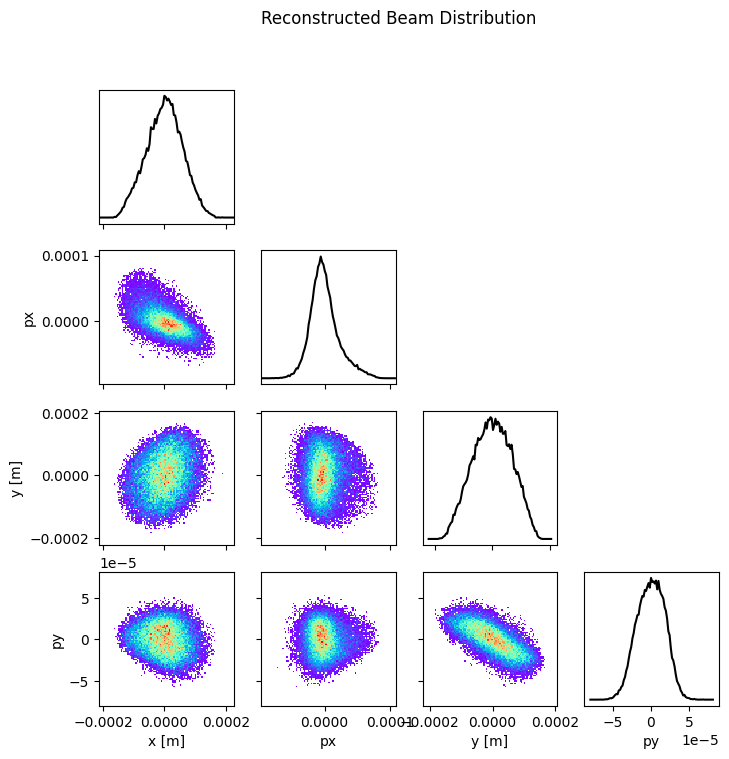

In [7]:
# Get the reconstructed beam from the trained generator
reconstructed_beam = trained_model.beam_generator()

# Plot the reconstructed beam distribution
# Assuming ParticleBeam or TransverseBeam4D has a plot_distribution() method
reconstructed_beam.plot_distribution()
plt.suptitle("Reconstructed Beam Distribution")
plt.show()

In [8]:
print("\nCalculating Emittance from Reconstructed Beam:")

x_coords = reconstructed_beam.x.clone().detach()
px_coords = reconstructed_beam.px.clone().detach()
y_coords = reconstructed_beam.y.clone().detach()
py_coords = reconstructed_beam.py.clone().detach()

x_squared = torch.mean(x_coords**2)
px_squared = torch.mean(px_coords**2)
x_px_cross = torch.mean(x_coords * px_coords)

y_squared = torch.mean(y_coords**2)
py_squared = torch.mean(py_coords**2)
y_py_cross = torch.mean(y_coords * py_coords)

print(f"<x^2> = {x_squared.item():.4e}")
print(f"<px^2> = {px_squared.item():.4e}")
print(f"<xpx> = {x_px_cross.item():.4e}")
print(f"<y^2> = {y_squared.item():.4e}")
print(f"<py^2> = {py_squared.item():.4e}")
print(f"<ypy> = {y_py_cross.item():.4e}")

# Emittance calculation
emittance_x = torch.sqrt(torch.abs(x_squared * px_squared - x_px_cross**2)) # Use abs for numerical stability
alpha_x = -x_px_cross / emittance_x
beta_x = x_squared / emittance_x
gamma_x = px_squared / emittance_x # Add gamma_x for completeness

print(f'\nReconstructed Emittance x: {emittance_x.item():.4e} m.rad')
print(f'Reconstructed Alpha x: {alpha_x.item():.4f}')
print(f'Reconstructed Beta x: {beta_x.item():.4f} m')
# print(f'Reconstructed Gamma x: {gamma_x.item():.4f} rad/m')

emittance_y = torch.sqrt(torch.abs(y_squared * py_squared - y_py_cross**2)) # Use abs for numerical stability
alpha_y = -y_py_cross / emittance_y
beta_y = y_squared / emittance_y
gamma_y = py_squared / emittance_y # Add gamma_y for completeness

print(f'\nReconstructed Emittance y: {emittance_y.item():.4e} m.rad')
print(f'Reconstructed Alpha y: {alpha_y.item():.4f}')
print(f'Reconstructed Beta y: {beta_y.item():.4f} m')
# print(f'Reconstructed Gamma y: {gamma_y.item():.4f} rad/m')


print("\nOriginal (Target) Values for Comparison:")

print(f'Target Emittance x: {torch.tensor(6.645688285621224e-10).item():.4e} m.rad')
print(f'Target Alpha x: {torch.tensor(0.9628247831366624).item():.4f}')
print(f'Target Beta x: {torch.tensor(5.349556897208785).item():.4f} m')

print(f'\nTarget Emittance y: {torch.tensor(8.907483248638635e-10).item():.4e} m.rad')
print(f'Target Alpha y: {torch.tensor(1.1845382840223906).item():.4f}')
print(f'Target Beta y: {torch.tensor(6.047631945676178).item():.4f} m')

emittance_results = {
    'emittance_x': emittance_x.item(),
    'alpha_x': alpha_x.item(),
    'beta_x': beta_x.item(),
    'emittance_y': emittance_y.item(),
    'alpha_y': alpha_y.item(),
    'beta_y': beta_y.item(),
    'target_emittance_x': torch.tensor(6.645688285621224e-10).item(),
    'target_emittance_y': torch.tensor(8.907483248638635e-10).item(),
    'target_alpha_x': torch.tensor(0.9628247831366624).item(),
    'target_alpha_y': torch.tensor(1.1845382840223906).item(),
    'target_beta_x': torch.tensor(5.349556897208785).item(),
    'target_beta_y': torch.tensor(6.047631945676178).item()
}


Calculating Emittance from Reconstructed Beam:
<x^2> = 3.3847e-09
<px^2> = 4.8284e-10
<xpx> = -7.2536e-10
<y^2> = 4.4463e-09
<py^2> = 3.2059e-10
<ypy> = -8.1491e-10

Reconstructed Emittance x: 1.0527e-09 m.rad
Reconstructed Alpha x: 0.6891
Reconstructed Beta x: 3.2153 m

Reconstructed Emittance y: 8.7255e-10 m.rad
Reconstructed Alpha y: 0.9339
Reconstructed Beta y: 5.0957 m

Original (Target) Values for Comparison:
Target Emittance x: 6.6457e-10 m.rad
Target Alpha x: 0.9628
Target Beta x: 5.3496 m

Target Emittance y: 8.9075e-10 m.rad
Target Alpha y: 1.1845
Target Beta y: 6.0476 m


In [9]:
from ps_reconstruction.core.results import save_results_to_logs

version = 45
test_batch = next(iter(test_dataloader))

# Move test batch data to device
target_images_test = test_batch['images'].to(device)
r11_test = test_batch['r11'].to(device)
r12_test = test_batch['r12'].to(device)
r33_test = test_batch['r33'].to(device)
r34_test = test_batch['r34'].to(device)
quad_k_test = test_batch['quad_k'].to(device) # Quad K for plotting

# Generate predicted images for the test set
# It's crucial to put the model in evaluation mode and use torch.no_grad() for inference
trained_model.eval()
with torch.no_grad():
    predicted_images_test = trained_model(
        r11=r11_test, r12=r12_test, r33=r33_test, r34=r34_test, quad_k=quad_k_test
    )

save_results_to_logs(reconstructed_beam=reconstructed_beam, 
                     target_images_test=target_images_test, 
                     predicted_images_test=predicted_images_test[:,0], 
                     quad_k_test=quad_k_test,
                     emittance_results=emittance_results,
                     logger_log_dir=f'./logs/beam_training/version_{version}')

Saving results to: ./logs/beam_training/version_45/final_results
✓ Saved reconstructed beam to: ./logs/beam_training/version_45/final_results/reconstructed_beam.pt
✓ Saved beam distribution plot to: ./logs/beam_training/version_45/final_results/reconstructed_beam_distribution.png
✓ Saved emittance results to: ./logs/beam_training/version_45/final_results/emittance_results.txt
Creating sigma comparison plots and CSV...
✓ Saved sigma comparison plot to: ./logs/beam_training/version_45/final_results/sigma_comparison.png
✓ Saved sigma values to CSV: ./logs/beam_training/version_45/final_results/sigma_values.csv
Creating concatenated comparison images...
Creating concatenated comparison images with sigma values...
✓ Saved comparison images to: ./logs/beam_training/version_45/final_results/test_images_comparison.png


'./logs/beam_training/version_45/final_results'

<Figure size 1200x1000 with 0 Axes>

Generating predictions for test set...


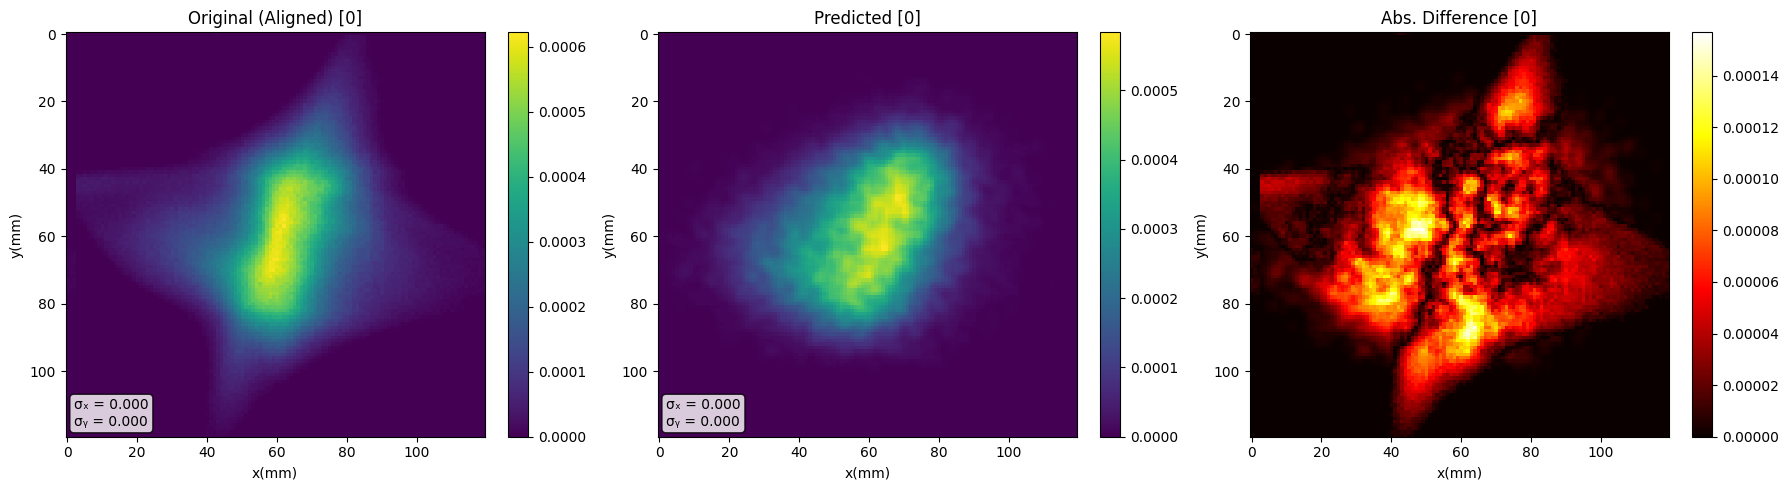

Image [0] - Original: σₓ=0.0001, σᵧ=0.0001
Image [0] - Predicted: σₓ=0.0001, σᵧ=0.0001
--------------------------------------------------


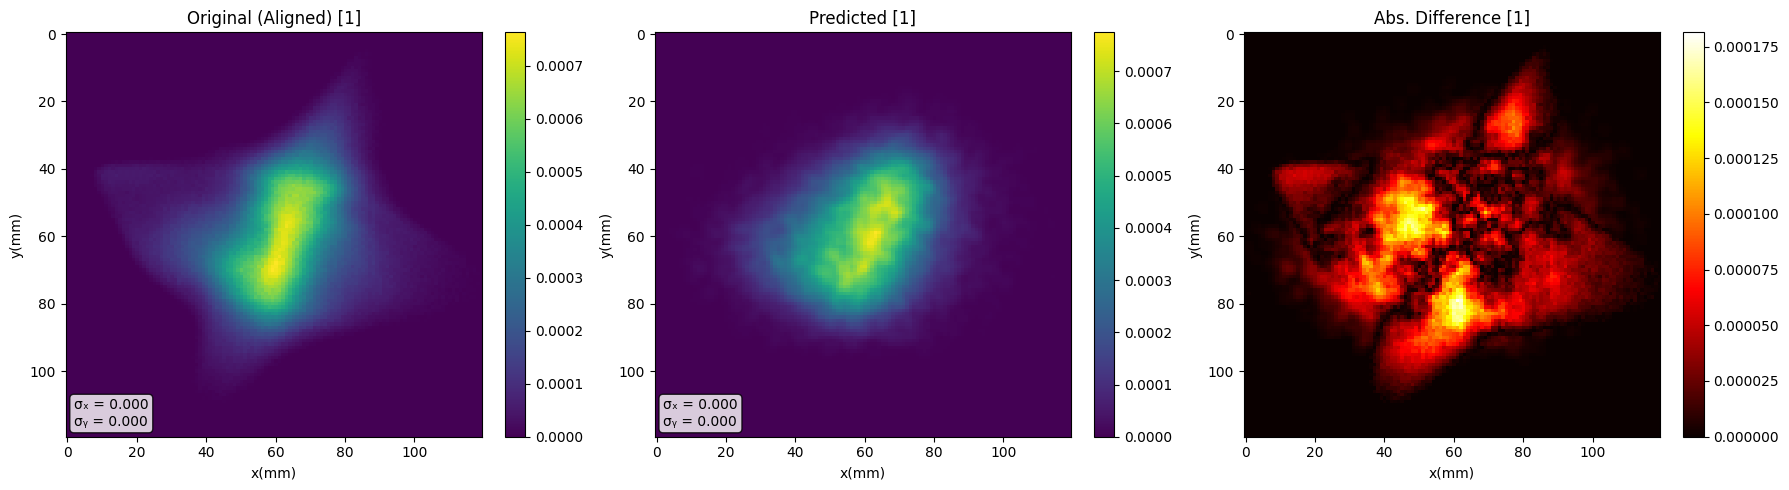

Image [1] - Original: σₓ=0.0001, σᵧ=0.0001
Image [1] - Predicted: σₓ=0.0001, σᵧ=0.0001
--------------------------------------------------


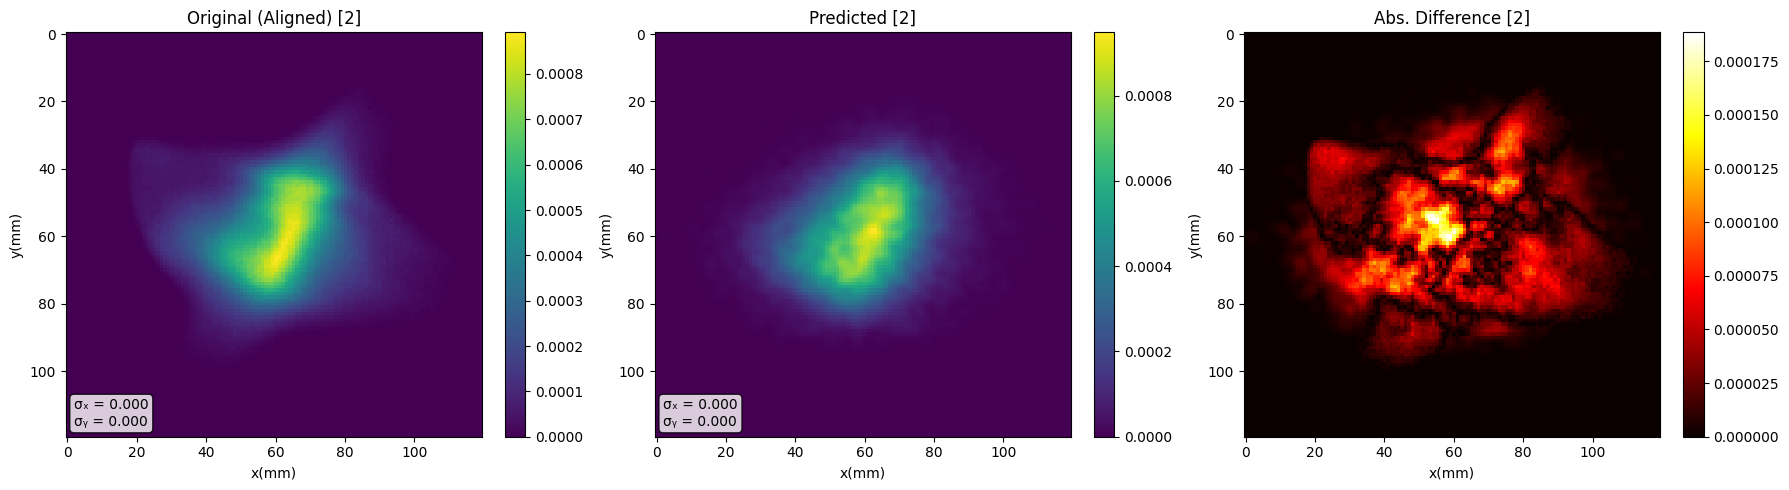

Image [2] - Original: σₓ=0.0001, σᵧ=0.0001
Image [2] - Predicted: σₓ=0.0001, σᵧ=0.0001
--------------------------------------------------


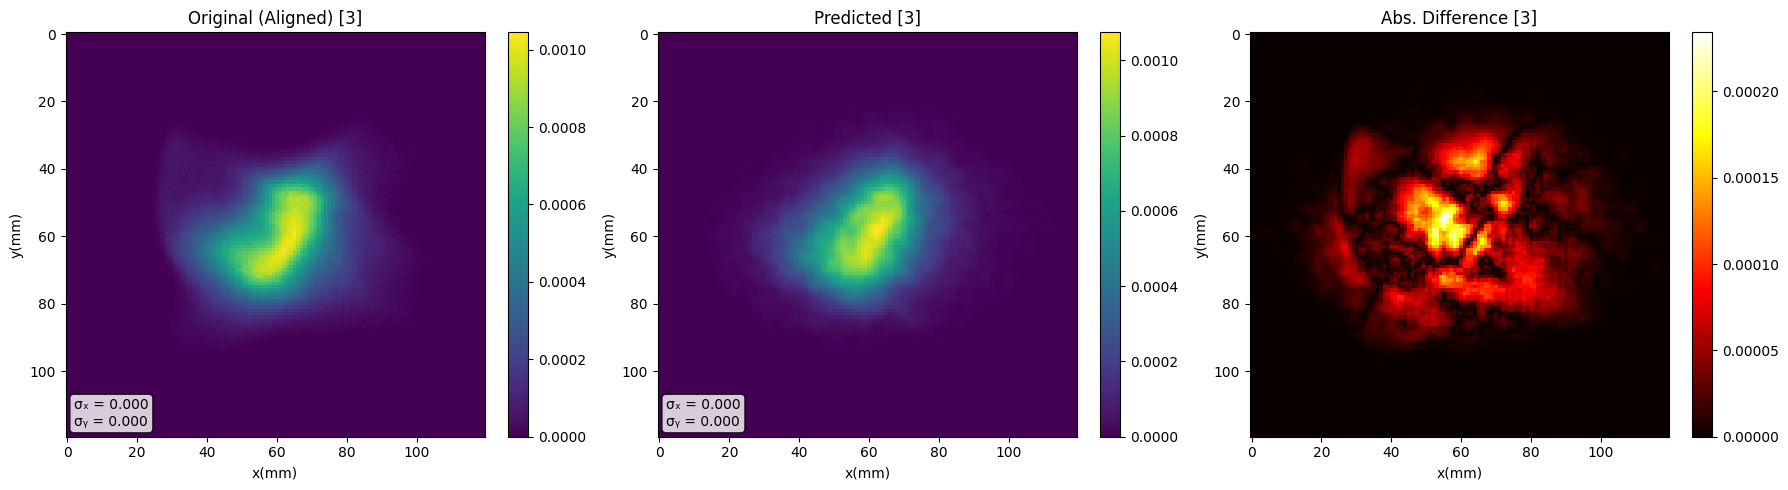

Image [3] - Original: σₓ=0.0001, σᵧ=0.0001
Image [3] - Predicted: σₓ=0.0001, σᵧ=0.0001
--------------------------------------------------


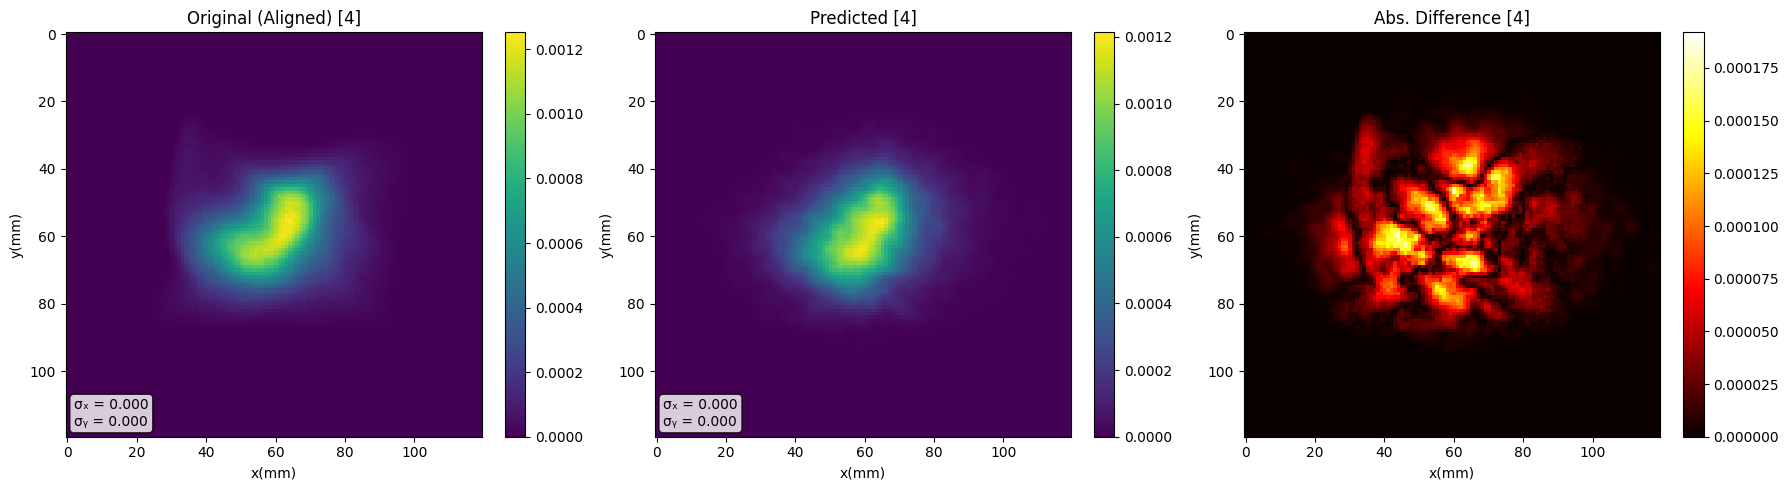

Image [4] - Original: σₓ=0.0001, σᵧ=0.0001
Image [4] - Predicted: σₓ=0.0001, σᵧ=0.0001
--------------------------------------------------


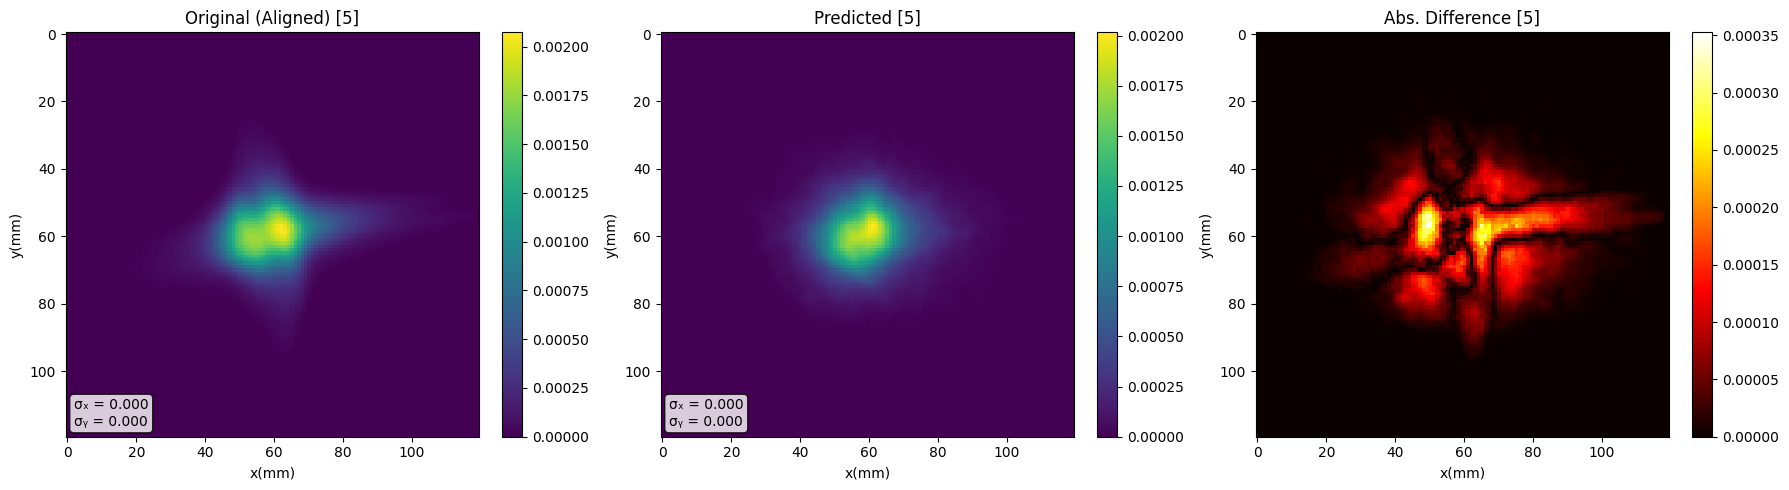

Image [5] - Original: σₓ=0.0001, σᵧ=0.0001
Image [5] - Predicted: σₓ=0.0001, σᵧ=0.0001
--------------------------------------------------


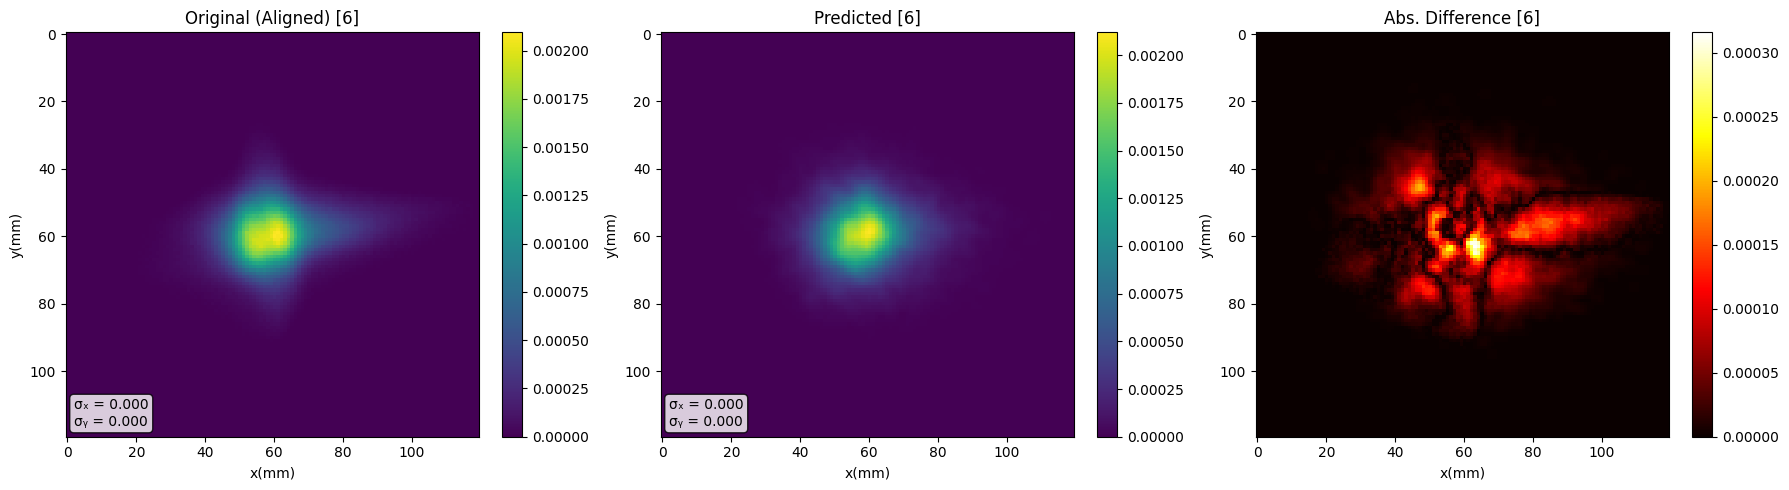

Image [6] - Original: σₓ=0.0001, σᵧ=0.0001
Image [6] - Predicted: σₓ=0.0001, σᵧ=0.0001
--------------------------------------------------


<Figure size 640x480 with 0 Axes>

In [28]:
print("Generating predictions for test set...")

# Iterate through the test dataloader (should be a single batch due to batch_size=len(test_ds))
test_batch = next(iter(train_dataloader))

# Move test batch data to device
target_images_test = test_batch['images'].to(device)
r11_test = test_batch['r11'].to(device)
r12_test = test_batch['r12'].to(device)
r33_test = test_batch['r33'].to(device)
r34_test = test_batch['r34'].to(device)
quad_k_test = test_batch['quad_k'].to(device) # Quad K for plotting

# Generate predicted images for the test set
# It's crucial to put the model in evaluation mode and use torch.no_grad() for inference
trained_model.eval()
with torch.no_grad():
    predicted_images_test = trained_model(
        r11=r11_test, r12=r12_test, r33=r33_test, r34=r34_test, quad_k=quad_k_test
    )

# This function expects original and predicted images as numpy arrays, which is why we convert them above.
plot_original_predicted_difference(
    original=target_images_test,
    predicted=predicted_images_test[:,0],
    # quad_k_values=quad_k_test.cpu().numpy()
)
plt.suptitle("Original, Predicted, and Difference Images (Test Set)")
plt.show()